In [ ]:
import kagglehub
kagglehub.login()


In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('vk-predict-cmc-hackathon', output_dir='../data')

print("Path to competition files:", path)

100%|██████████| 502M/502M [04:50<00:00, 1.81MB/s] 

Extracting files...


Path to competition files: ../data


In [8]:
import sys
import os

sys.path.append(os.path.abspath('..'))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import proccess_data

In [9]:
df = pd.read_csv('../data/train.csv')

sample_df = proccess_data.get_sample_data('data/train.csv', 0.2)

In [10]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49594 entries, 242734 to 124902
Columns: 1369 entries, index to feature_1366
dtypes: float64(1361), int64(8)
memory usage: 518.4 MB


In [18]:
df.head()

,index,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
0,239134,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,1,1,1,1,1,0
1,234708,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,1.0,...,-1.0,-1.0,-1.0,1,1,1,1,0,0,1
2,268300,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,4.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,283077,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,337271,1.0,0.5,0.5,1.0,1.0,1.0,9.0,1.0,1.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247972 entries, 0 to 247971
Columns: 1369 entries, index to feature_1366
dtypes: float64(1361), int64(8)
memory usage: 2.5 GB


In [9]:
df.describe()

,index,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
count,247972.000000,247972.000000,247972.0,247972.0,247972.0,247972.0,247972.000000,247972.000000,247972.000000,247972.000000,...,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000
mean,177081.186364,0.013493,0.5,0.5,1.0,1.0,0.794473,1.864892,1.270490,1.457911,...,-0.143246,-0.145520,-0.149049,0.121848,0.136741,0.096204,0.034742,0.139403,0.190792,0.149783
std,102245.504744,0.115375,0.0,0.0,0.0,0.0,0.715883,1.802944,0.919966,1.622873,...,0.368512,0.364513,0.358193,0.327111,0.343575,0.294872,0.183126,0.346367,0.392926,0.356859
min,2.000000,0.000000,0.5,0.5,1.0,1.0,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,88544.750000,0.000000,0.5,0.5,1.0,1.0,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,177110.500000,0.000000,0.5,0.5,1.0,1.0,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,265596.750000,0.000000,0.5,0.5,1.0,1.0,1.000000,3.000000,2.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,354243.000000,1.000000,0.5,0.5,1.0,1.0,13.000000,30.000000,23.000000,31.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


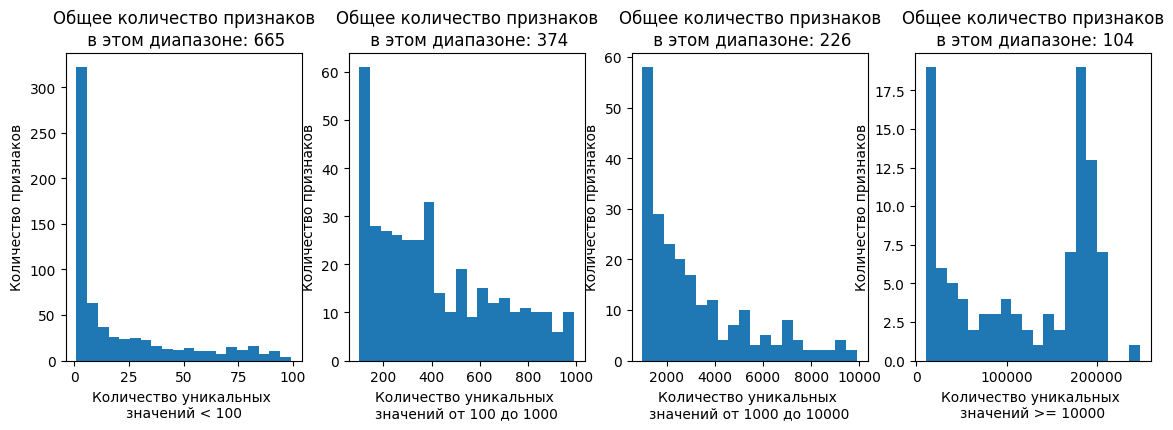

In [ ]:
uniq_values = {col: df[col].unique() for col in df.columns}

num_of_unique_values = np.array([len(df[col].unique()) for col in df.columns])

fig, ax = plt.subplots(1, 4, figsize=(14, 4))

num_of_uniq_filt = num_of_unique_values[num_of_unique_values < 100]
ax[0].hist(list(num_of_uniq_filt), bins=20)
ax[0].set_xlabel("Количество уникальных \nзначений < 100")
ax[0].set_ylabel("Количество признаков")
ax[0].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))

num_of_uniq_filt = num_of_unique_values[(num_of_unique_values >= 100) & (num_of_unique_values < 1000)]
ax[1].hist(list(num_of_uniq_filt), bins=20)
ax[1].set_xlabel("Количество уникальных \nзначений от 100 до 1000")
ax[1].set_ylabel("Количество признаков")
ax[1].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))

num_of_uniq_filt = num_of_unique_values[(num_of_unique_values >= 1000) & (num_of_unique_values < 10000)]
ax[2].hist(list(num_of_uniq_filt), bins=20)
ax[2].set_xlabel("Количество уникальных \nзначений от 1000 до 10000")
ax[2].set_ylabel("Количество признаков")
ax[2].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))


num_of_uniq_filt = num_of_unique_values[num_of_unique_values >= 10000]
ax[3].hist(list(num_of_uniq_filt), bins=20)
ax[3].set_xlabel("Количество уникальных \nзначений >= 10000")
ax[3].set_ylabel("Количество признаков")
ax[3].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))


plt.show()
None

бОльшая часть признаков имеют распределение на конечном множестве, меньше 100 признаков имеют какое-то распределение на всем $\mathbb{R}$